In [10]:
import duckdb
import pandas as pd

PARQUET_PATH = "../data/occurrences.parquet"

df = pd.read_parquet(PARQUET_PATH)

print(f"Records: {len(df):,}")
print(f"Columns: {len(df.columns)}")

df.head()

Records: 663
Columns: 16


,gbifID,scientificName,species,kingdom,phylum,class,order,family,genus,country,countryCode,decimalLatitude,decimalLongitude,eventDate,basisOfRecord,occurrenceStatus
0,6274122513,"Hynobius nebulosus (Temminck & Schlegel, 1838)",Hynobius nebulosus,Animalia,Chordata,Amphibia,Caudata,Hynobiidae,Hynobius,Japan,JP,33.584885,130.274533,2026-01-22T20:37:14,HUMAN_OBSERVATION,PRESENT
1,6234740240,"Hynobius nebulosus (Temminck & Schlegel, 1838)",Hynobius nebulosus,Animalia,Chordata,Amphibia,Caudata,Hynobiidae,Hynobius,Japan,JP,33.412360,130.257765,2026-04-16T20:37,HUMAN_OBSERVATION,PRESENT
2,6398873387,"Hynobius nebulosus (Temminck & Schlegel, 1838)",Hynobius nebulosus,Animalia,Chordata,Amphibia,Caudata,Hynobiidae,Hynobius,Japan,JP,33.693447,130.358100,2026-04-16T19:55,HUMAN_OBSERVATION,PRESENT
3,6399730327,"Hynobius nebulosus (Temminck & Schlegel, 1838)",Hynobius nebulosus,Animalia,Chordata,Amphibia,Caudata,Hynobiidae,Hynobius,Japan,JP,33.778667,130.370468,2026-04-16T20:23,HUMAN_OBSERVATION,PRESENT
4,6400292059,"Hynobius nebulosus (Temminck & Schlegel, 1838)",Hynobius nebulosus,Animalia,Chordata,Amphibia,Caudata,Hynobiidae,Hynobius,Japan,JP,33.630736,130.284465,2026-04-16T20:02,HUMAN_OBSERVATION,PRESENT


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 663 entries, 0 to 662
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gbifID            663 non-null    object 
 1   scientificName    663 non-null    object 
 2   species           663 non-null    object 
 3   kingdom           663 non-null    object 
 4   phylum            663 non-null    object 
 5   class             663 non-null    object 
 6   order             663 non-null    object 
 7   family            663 non-null    object 
 8   genus             663 non-null    object 
 9   country           624 non-null    object 
 10  countryCode       624 non-null    object 
 11  decimalLatitude   407 non-null    float64
 12  decimalLongitude  407 non-null    float64
 13  eventDate         528 non-null    object 
 14  basisOfRecord     663 non-null    object 
 15  occurrenceStatus  663 non-null    object 
dtypes: float64(2), object(14)
memory usage: 83.0

In [12]:
df.isna().sum().sort_values(ascending=False).head(20)

decimalLongitude    256
decimalLatitude     256
eventDate           135
country              39
countryCode          39
gbifID                0
species               0
scientificName        0
family                0
order                 0
class                 0
phylum                0
kingdom               0
genus                 0
basisOfRecord         0
occurrenceStatus      0
dtype: int64

## 2. データ品質

取得した663件のGBIF occurrenceデータについて、各カラムの欠損状況を確認する。

特に位置情報（緯度・経度）と観察日（eventDate）には欠損が存在するため、
後続の地理分析・時系列分析では欠損データを考慮する必要がある。

In [13]:
missing = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

missing

decimalLongitude    256
decimalLatitude     256
eventDate           135
country              39
countryCode          39
dtype: int64

In [14]:
missing_rate = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_rate = missing_rate[missing_rate > 0]

missing_rate

decimalLongitude    38.612368
decimalLatitude     38.612368
eventDate           20.361991
country              5.882353
countryCode          5.882353
dtype: float64

Matplotlib is building the font cache; this may take a moment.


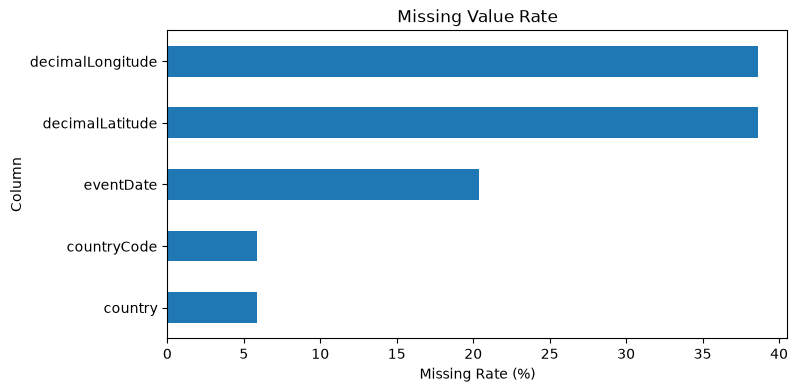

In [15]:
import matplotlib.pyplot as plt

missing_rate.sort_values().plot(
    kind="barh",
    figsize=(8, 4),
    title="Missing Value Rate",
)

plt.xlabel("Missing Rate (%)")
plt.ylabel("Column")
plt.show()

## 3. Species別の観察記録

GBIF APIから取得したレコードが、実際にどの分類群に紐づいているかを確認する。

In [16]:
species_counts = (
    df.groupby("scientificName")
    .size()
    .sort_values(ascending=False)
)

species_counts

scientificName
Hynobius nebulosus (Temminck & Schlegel, 1838)              325
Hynobius nebulosus nebulosus (Temminck & Schlegel, 1838)    186
Hynobius peropus Boulenger, 1882                            148
BOLD:AAI8551                                                  4
dtype: int64

### 考察

`Hynobius nebulosus` を検索条件としてGBIF occurrence APIを利用したが、
取得結果には検索対象とは異なる `scientificName` も含まれていた。

そのため、GBIF APIから取得したデータをそのまま分析対象とするのではなく、
分類情報を確認した上で、分析対象となるレコードを定義する必要がある。

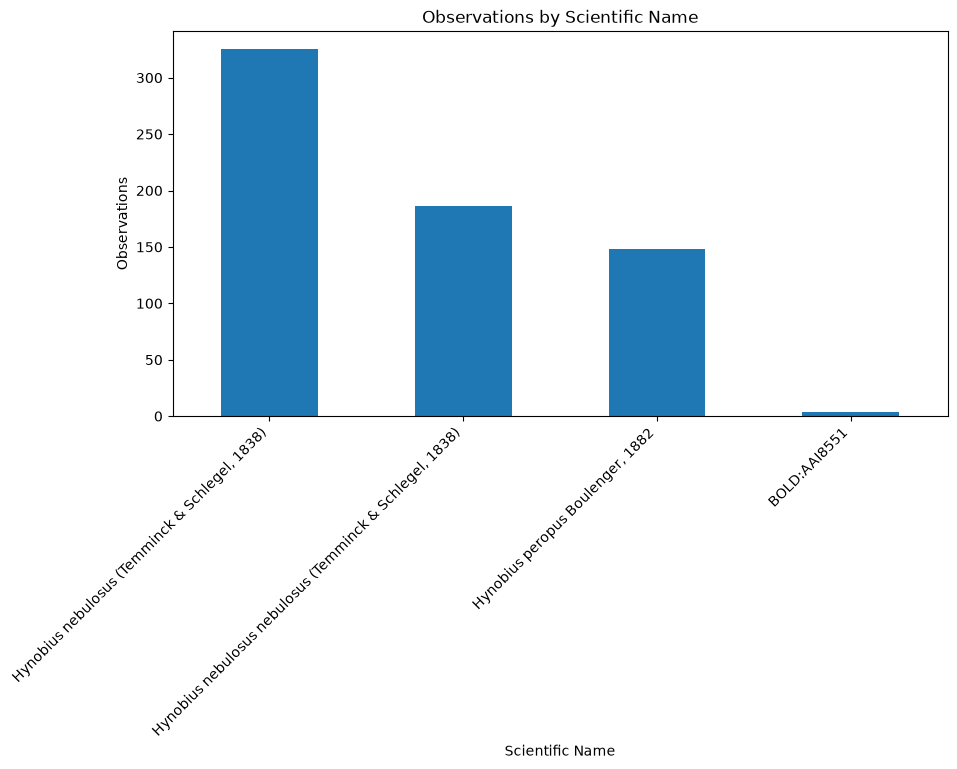

In [17]:
species_counts.plot(
    kind="bar",
    figsize=(10, 5),
    title="Observations by Scientific Name",
)

plt.xlabel("Scientific Name")
plt.ylabel("Observations")
plt.xticks(rotation=45, ha="right")
plt.show()

## 4. Country別の観察記録

GBIF occurrenceデータを国別に集計し、観察記録がどの地域に集中しているかを確認する。

`countryCode` が欠損しているレコードについては、`UNKNOWN` として扱う。

In [18]:
country_counts = (
    df.assign(
        countryCode=df["countryCode"].fillna("UNKNOWN")
    )
    .groupby("countryCode")
    .size()
    .sort_values(ascending=False)
)

country_counts

countryCode
JP         622
UNKNOWN     39
VN           2
dtype: int64

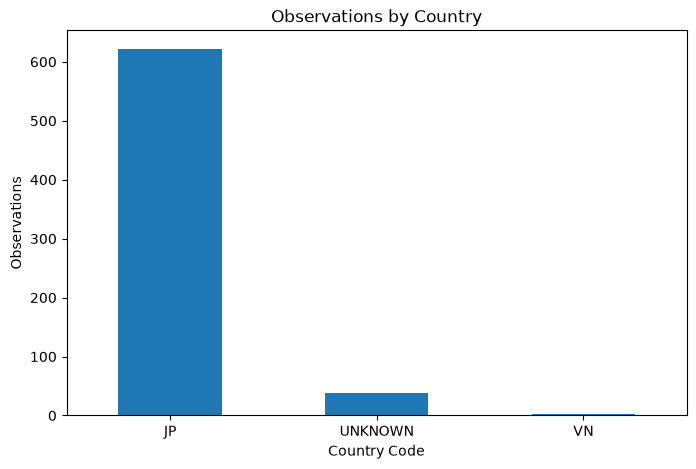

In [19]:
country_counts.plot(
    kind="bar",
    figsize=(8, 5),
    title="Observations by Country",
)

plt.xlabel("Country Code")
plt.ylabel("Observations")
plt.xticks(rotation=0)
plt.show()

In [20]:
country_rate = (
    country_counts
    .div(country_counts.sum())
    .mul(100)
    .round(1)
)

country_rate

countryCode
JP         93.8
UNKNOWN     5.9
VN          0.3
dtype: float64

### 考察

観察記録の大部分は日本（JP）に集中している。

一方、39件のレコードでは `countryCode` が欠損している。
そのため、国別分析では欠損値を除外するのではなく、`UNKNOWN` として
明示的に扱うことで、データ欠損の存在を維持した。

また、`countryCode` が `JP` 以外のレコードも存在するため、
検索対象の分類群と地理情報の組み合わせについても確認する必要がある。

In [21]:
unknown_country = (
    df[df["countryCode"].isna()]
    .groupby("scientificName")
    .size()
    .sort_values(ascending=False)
)

unknown_country

scientificName
Hynobius nebulosus (Temminck & Schlegel, 1838)    37
BOLD:AAI8551                                       2
dtype: int64

### Country情報が欠損しているレコード

`countryCode` が欠損している39件について分類群別に確認したところ、
37件が `Hynobius nebulosus`、2件が `BOLD:AAI8551` だった。

このことから、国情報の欠損は特定の分類群に偏っていることが分かった。

ただし、`countryCode` の欠損だけからデータ自体が不正であるとは判断できない。
GBIFでは位置情報が保護目的などで非公開・粗い精度に変更される場合もあるため、
分析では欠損の理由を考慮する必要がある。

In [26]:
year_counts = (
    df["eventDate"]
    .dropna()
    .astype(str)
    .str[:4]
    .astype(int)
    .value_counts()
    .sort_index()
)

year_counts

eventDate
1800      1
1818      2
1890      1
1903      1
1904      2
1905      2
1907      1
1910    333
1919      1
1929      1
1931      3
1935      1
1946      2
1950      1
1957     10
1958      2
1959      1
1964      2
1965      7
1966     10
1969      7
1970      5
1972      6
1973      7
1974      1
1976      1
1977      9
1978      1
1979      1
1980      3
1981      1
1982      2
1983      2
1984      1
1985      6
1986      3
1987      1
1988     15
1989      2
1990      6
1996      2
1997     12
2000      1
2005      1
2006      4
2011      1
2013     13
2014      1
2016      2
2018     16
2021      1
2022      1
2023      2
2026      7
Name: count, dtype: int64

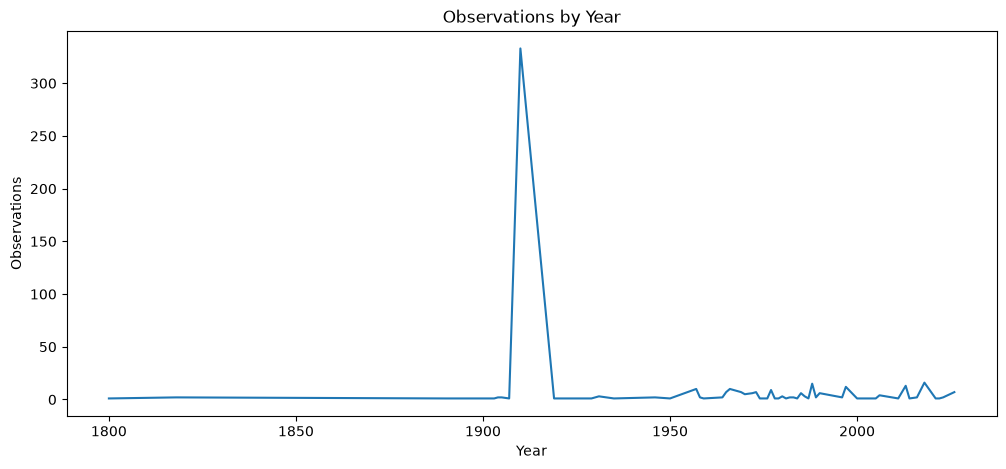

In [27]:
year_counts.plot(
    figsize=(12, 5),
    title="Observations by Year",
)

plt.xlabel("Year")
plt.ylabel("Observations")
plt.show()

In [28]:
df_1910 = df[
    df["eventDate"]
    .fillna("")
    .astype(str)
    .str.startswith("1910")
]

df_1910["basisOfRecord"].value_counts()

basisOfRecord
PRESERVED_SPECIMEN    333
Name: count, dtype: int64

In [29]:
df_1910["scientificName"].value_counts()

scientificName
Hynobius nebulosus nebulosus (Temminck & Schlegel, 1838)    184
Hynobius peropus Boulenger, 1882                            146
Hynobius nebulosus (Temminck & Schlegel, 1838)                3
Name: count, dtype: int64

In [30]:
df_1910[
    [
        "scientificName",
        "eventDate",
        "basisOfRecord",
        "countryCode",
    ]
].head(20)

,scientificName,eventDate,basisOfRecord,countryCode
185,"Hynobius nebulosus (Temminck & Schlegel, 1838)",1910-10-01/1910-10-04,PRESERVED_SPECIMEN,JP
186,Hynobius nebulosus nebulosus (Temminck & Schle...,1910-10,PRESERVED_SPECIMEN,JP
187,Hynobius nebulosus nebulosus (Temminck & Schle...,1910-10,PRESERVED_SPECIMEN,JP
188,Hynobius nebulosus nebulosus (Temminck & Schle...,1910-10,PRESERVED_SPECIMEN,JP
189,Hynobius nebulosus nebulosus (Temminck & Schle...,1910-10,PRESERVED_SPECIMEN,JP
190,Hynobius nebulosus nebulosus (Temminck & Schle...,1910-10,PRESERVED_SPECIMEN,JP
191,Hynobius nebulosus nebulosus (Temminck & Schle...,1910-10,PRESERVED_SPECIMEN,JP
192,Hynobius nebulosus nebulosus (Temminck & Schle...,1910-10,PRESERVED_SPECIMEN,JP
193,Hynobius nebulosus nebulosus (Temminck & Schle...,1910-10,PRESERVED_SPECIMEN,JP
194,Hynobius nebulosus nebulosus (Temminck & Schle...,1910-10,PRESERVED_SPECIMEN,JP


In [ ]:
## 5.2 1910年の異常値を調査

年別集計では1910年に333件のレコードが集中していた。

この件数が実際の観察活動を示しているのかを確認するため、
1910年のレコードについて `basisOfRecord` と `scientificName` を調査した。

In [31]:
df_1910["basisOfRecord"].value_counts()

basisOfRecord
PRESERVED_SPECIMEN    333
Name: count, dtype: int64

In [32]:
df_1910["scientificName"].value_counts()

scientificName
Hynobius nebulosus nebulosus (Temminck & Schlegel, 1838)    184
Hynobius peropus Boulenger, 1882                            146
Hynobius nebulosus (Temminck & Schlegel, 1838)                3
Name: count, dtype: int64

### 考察

1910年の333件はすべて `PRESERVED_SPECIMEN` であり、
保存標本に由来するレコードだった。

また、分類群を見ると `Hynobius nebulosus nebulosus` が184件、
`Hynobius peropus` が146件を占めていた。

したがって、1910年の件数の急増は、1910年に観察活動が集中したことを
直接意味するものではない。

この結果から、GBIFの時系列データを分析する際には、
単純な年別件数だけでなく `basisOfRecord` などのデータ属性を確認し、
レコードがどのように生成されたかを考慮する必要がある。

In [33]:
basis_counts = (
    df["basisOfRecord"]
    .value_counts()
)

basis_counts

basisOfRecord
PRESERVED_SPECIMEN    636
MATERIAL_SAMPLE        17
HUMAN_OBSERVATION      10
Name: count, dtype: int64

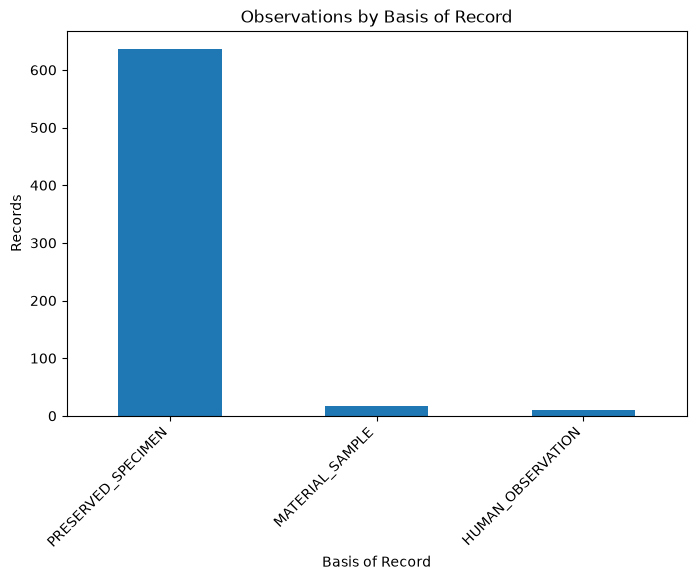

In [34]:
basis_counts.plot(
    kind="bar",
    figsize=(8, 5),
    title="Observations by Basis of Record",
)

plt.xlabel("Basis of Record")
plt.ylabel("Records")
plt.xticks(rotation=45, ha="right")
plt.show()